# Learning CNN for Image Classification

In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

keras.utils.set_random_seed(42)

In [17]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

In [18]:
labels = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

In [19]:
def plot_loss(history):
    plt.clf()
    history_dict = history.history
    loss_values = history_dict["loss"]
    val_loss_values = history_dict["val_loss"]
    epochs = range(1, len(loss_values) + 1)
    plt.plot(epochs, loss_values, "bo", label="Training Loss") # bo => plot blue circles only 
    plt.plot(epochs, val_loss_values, "b", label="Validation Loss") # b => plot blue line
    plt.title("Training and Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


In [20]:
def plot_acc(history):
    plt.clf()
    history_dict = history.history
    acc = history_dict["accuracy"]
    val_acc = history_dict["val_accuracy"]
    epochs = range(1, len(acc) + 1)
    plt.plot(epochs, acc, "bo", label="Training acc") # bo => plot blue circles only 
    plt.plot(epochs, val_acc, "b", label="Validation acc") # b => plot blue line
    plt.title("Training and Validation acc")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


In [21]:
x_train.shape

(60000, 28, 28)

In [22]:
x_train.shape[1:]

(28, 28)

# Data prep

We will normalize the values of the input before defining the model

In [23]:
# add another dimension (from 28x28 => 28x28x1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Define Model

In [24]:
input = keras.Input(shape=(x_train.shape[1:]))

# normalize values

x = keras.layers.Rescaling(1./255)(input)

# FIRST Convolutional Block

x = keras.layers.Conv2D(32,
                        kernel_size=(2, 2),
                        activation="relu",
                        name="Conv_1")(x)
# pooling layer

x = keras.layers.MaxPool2D()(x)

# END FIRST Convolutional Block

# SECOND Convolutional Block

x = keras.layers.Conv2D(32, #number of filters
                        kernel_size=(2, 2), # shape of each filter
                        activation="relu", # RELU activation 
                        name="Conv_2")(x)

# pooling layer

x = keras.layers.MaxPool2D()(x)

# END of SECOND Convolutional Block

# flatten layer

x = keras.layers.Flatten()(x)

# dense ReLU layer

x = keras.layers.Dense(256, activation="relu")(x)

# output softmax 

output = keras.layers.Dense(10, activation="softmax")(x)

model = keras.Model(input, output)


In [25]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 27, 27, 32)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 12, 12, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 302,026 (1.15 MB)

 Trainable params: 302,026 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

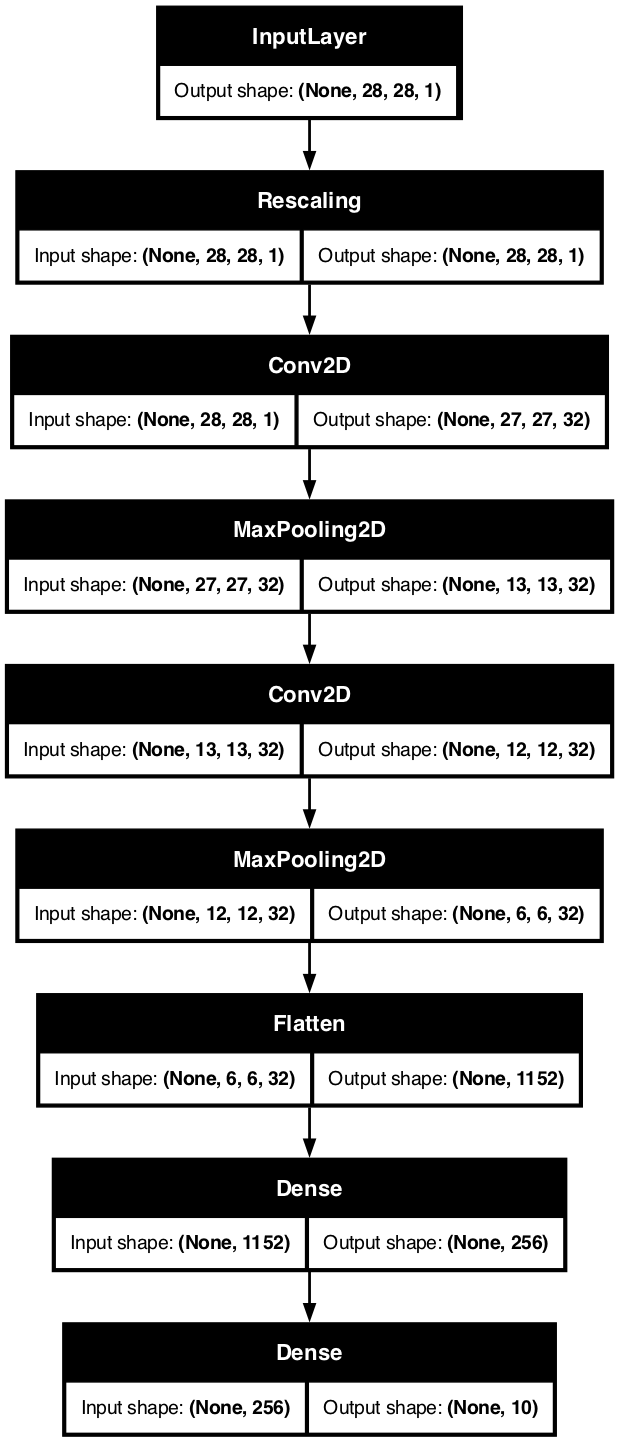

In [26]:
keras.utils.plot_model(model, show_shapes=True, dpi=100)

In [27]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

In [28]:
history = model.fit(x_train,
                    y_train,
                    batch_size=64,
                    epochs=10,
                    validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8219 - loss: 0.4996 - val_accuracy: 0.8712 - val_loss: 0.3651
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8784 - loss: 0.3336 - val_accuracy: 0.8875 - val_loss: 0.3151
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8947 - loss: 0.2884 - val_accuracy: 0.8963 - val_loss: 0.2879
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9041 - loss: 0.2586 - val_accuracy: 0.9025 - val_loss: 0.2716
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9131 - loss: 0.2345 - val_accuracy: 0.9043 - val_loss: 0.2645
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9211 - loss: 0.2142 - val_accuracy: 0.9022 - val_loss: 0.2664
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9282 - loss: 0.1945 - val_accuracy: 0.9035 - val_loss: 0.2679
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9354 - loss: 0.1760 - val_accuracy: 0.

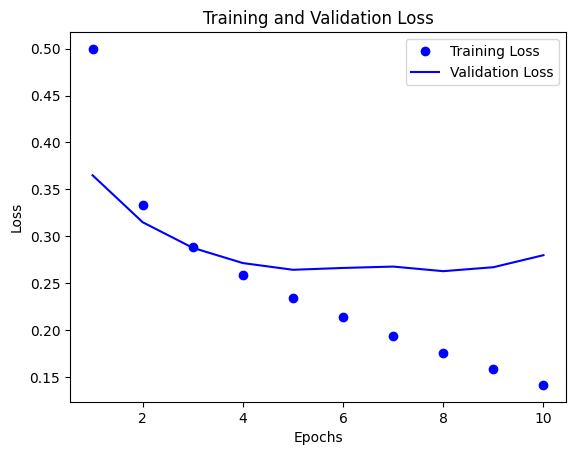

In [30]:
plot_loss(history)

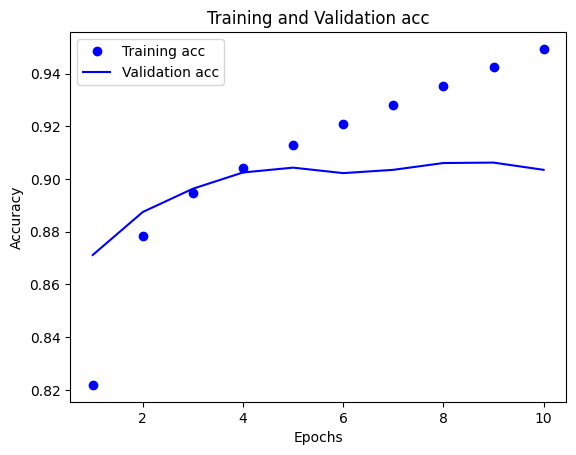

In [31]:
plot_acc(history)

In [32]:
score = model.evaluate(x_test, y_test)
print("Test acc:", score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 721us/step - accuracy: 0.9030 - loss: 0.2980
Test acc: 0.902999997138977
